In [12]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from tqdm import tqdm

# Анализ детерминированной задачи

Определим вспомогательные функции.

In [13]:
def find_jacobian(
    func: callable,
    t: float,
    state: np.ndarray,
    params: dict,
    eps: float = 1e-6,
) -> np.ndarray:
    n = len(state)
    jacobian = np.zeros((n, n))

    for i in range(n):
        perturb = np.zeros(n)
        perturb[i] = eps
        
        f1 = func(t, state + perturb, **params)
        f2 = func(t, state - perturb, **params)
        jacobian[:, i] = (f1 - f2) / (2 * eps)
    
    return jacobian

def find_equilibrium(
    func: callable,
    guess: np.ndarray,
    params: dict,
) -> np.ndarray:    
    def root_fn(state):
        return func(0, state, **params)
    
    solution, info, ier, _ = sp.optimize.fsolve(root_fn, guess, full_output=True)
    
    if ier == 1:
        return solution
    return None


def classify_equilibrium(
    eigenvalues: np.ndarray,
    eps: float = 1e-6
) -> str:
    real = np.real(eigenvalues)
    imag = np.imag(eigenvalues)

    if np.any(real > eps) and np.any(real < -eps):
        return 'saddle'

    if np.all(np.abs(real) < eps):
        if np.any(np.abs(imag) > eps):
            return 'center'
        else:
            return 'degenerate'

    if np.any(np.abs(imag) > eps):
        if np.all(real < 0):
            return 'stable focus'
        elif np.all(real > 0):
            return 'unstable focus'

    if np.all(real < 0):
        return 'stable node'
    elif np.all(real > 0):
        return 'unstable node'

    return 'unknown'

Определим класс двумерной динамической системы с возможностью нахождения решения методом Рунге-Кутты 4 порядка с суммарной ошибкой $O(h^4)$ на интервале решения, с возможностью построения бифуркационной диаграммы и фазового портрета системы, нахождения равновесий и предельных циклов.

In [14]:
class DynamicSystem2D:

    def __init__(
        self,
        model_func: callable,
        params: dict = None,
    ) -> None:
        """
        Args:
            model_func: function returning a vector of (dx/dt, dy/dt)
            params: dictionary of parameters
        """
        self.model_func = model_func
        self.params = params if params is not None else {}

    def solve(
        self,
        state_init: np.ndarray,
        time_span: np.ndarray
    ) -> np.ndarray:
        """
        Find numeric solution for the system using 4-th order Runge-Kutta method.
        
        Args:
            state_init: initial state (x_0, y_0) of the dynamic system
            time_span: uniform time grid
        
        Returns:
            solution: array system states per time point throughout the time span
        """
        n = len(time_span)
        h = time_span[1] - time_span[0]
        
        solution = np.zeros((n, len(state_init)))
        solution[0] = state_init.copy()

        for i in range(n - 1):
            t = time_span[i]
            state_curr = solution[i]
            
            k1 = h * self.model_func(t, state_curr, **self.params)
            k2 = h * self.model_func(t + h/2, state_curr + k1/2, **self.params)
            k3 = h * self.model_func(t + h/2, state_curr + k2/2, **self.params)
            k4 = h * self.model_func(t + h, state_curr + k3, **self.params)
            
            solution[i + 1] = state_curr + (k1 + 2 * k2 + 2 * k3 + k4) / 6
            
        return solution

    def plot_bifurcation_diagram(
        self,
        param_name: str,
        param_values: np.ndarray,
        state_init: np.ndarray,
        ax: plt.Axes,
    ) -> tuple[np.ndarray, np.ndarray]:
        """
        Plot bifurcation diagram for a dynamic system.

        Iterate over the dense grid of parameter values, and detect eigenvalue sign changes
        for Jacobians of equilibrium states, marking them as bifurcation points.

        Real part of the eigenvalues of the Jacobian indicates the system stability/instability
        per parameter value (<0 ==> stable, >0 ==> unstable).

        Returns:
            bifurcation_points: array of bifurcation.
            equilibria: array of equilibrium point coordinates.
        """
        equilibria = []
        stability_mask = []
        types = []
        param_used = []
        bifurcation_points = []

        eigenvalues_last = None

        for val in param_values:
            self.params[param_name] = val

            guess = self._resolve_state_init(
                state_init=state_init,
                val=val,
                prev_equilibrium=equilibria[-1] if len(equilibria) > 0 else None
            )

            equilibrium = find_equilibrium(
                func=self.model_func,
                guess=guess,
                params=self.params
            )

            if equilibrium is None:
                continue

            jacobian = find_jacobian(
                func=self.model_func,
                t=0,
                state=equilibrium,
                params=self.params
            )
            eigenvalues = np.linalg.eigvals(jacobian)

            # equillibrium classification
            eq_type = classify_equilibrium(eigenvalues)
            types.append(eq_type)

            is_stable = np.all(np.real(eigenvalues) < 0)
            stability_mask.append(is_stable)

            # bifurcation check
            if eigenvalues_last is not None:
                if np.any(np.real(eigenvalues_last) * np.real(eigenvalues) < 0):
                    bifurcation_points.append(val)
                    ax.axvline(val, linestyle='--', label='bifurcation point')

            equilibria.append(equilibrium)
            param_used.append(val)

            eigenvalues_last = eigenvalues
            state_init = equilibrium

        equilibria = np.array(equilibria)
        stability_mask = np.array(stability_mask)
        param_used = np.array(param_used)
        bifurcation_points = np.array(bifurcation_points)

        x_eq = equilibria[:, 0]

        type_to_color = {
            'stable node': 'blue',
            'unstable node': 'red',
            'saddle': 'black',
            'stable focus': 'green',
            'unstable focus': 'orange',
            'center': 'purple',
            'degenerate': 'gray',
        }

        for t in set(types):
            mask = np.array([tt == t for tt in types])
            ax.scatter(param_used[mask], x_eq[mask], label=t, color=type_to_color.get(t, 'gray'), s=20)

        ax.set_xlabel(param_name)
        ax.set_ylabel('x')
        ax.set_title('Bifurcation diagram (with equilibrium types)')
        ax.legend()
        ax.grid(True)

        return bifurcation_points, equilibria
    
    def plot_trajectory(
        self,
        state_init: np.ndarray,
        time_span: np.ndarray,
        ax: plt.Axes,
        label: str,
    ) -> None:
        """
        Plot trajectory for given initial state.
        """
        solution = self.solve(state_init, time_span)
        ax.plot(solution[:, 0], solution[:, 1], label=label)
        ax.set_title('Phase portrait')
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.legend(loc='upper right')
        ax.grid(True)
    
    def extract_limit_cycle(
        self,
        solution: np.ndarray,
        clip_ratio: float = 0.5,
        eps: float = 1e-4,
    ) -> np.ndarray | None:
        """
        Extract limit cycle from a trajectory if it exists.
        
        Returns:
            solution_ss: limit cycle (if found) or None
        """
        x = solution[:, 0]

        # clip transient (consider only the asymptotic behavior of the system)
        clip = int(len(x) * clip_ratio)
        solution_ss = solution[clip:]
        x_ss = solution_ss[:, 0]

        # check: is solution bounded
        if not np.all(np.isfinite(solution_ss)):
            return None
        
        # check: not an equilibrium (consider only cycles, not points)
        if np.var(x_ss) < eps:
            return None

        return solution_ss
    
    def plot_limit_cycle(
        self,
        ax: plt.Axes,
        time_span: np.ndarray,
        bounds: tuple = (-2, 2),
        n_attempts: int = 5,
    ) -> bool:
        """
        Try to detect and plot limit cycle.
        """
        found = False

        for _ in range(n_attempts):
            state_init = np.random.uniform(bounds[0], bounds[1], size=2)
            solution = self.solve(state_init, time_span)

            if not np.all(np.isfinite(solution)):
                continue

            cycle = self.extract_limit_cycle(solution)
            if cycle is not None:
                ax.plot(cycle[:, 0], cycle[:, 1], color='red', linewidth=2, label='limit cycle')
                found = True
                break

        return found

    def plot_phase_portrait_dense(
        self,
        ax: plt.Axes,
        time_span: np.ndarray,
        bounds: tuple = (-2, 2),
        grid_size: int = 10,
        show_limit_cycle: bool = True,
    ) -> None:
        """
        Plot phase portrait based on a grid of initial states.
        """
        xmin, xmax = bounds
        ymin, ymax = bounds

        # initialize grid
        x_vals = np.linspace(xmin, xmax, grid_size)
        y_vals = np.linspace(ymin, ymax, grid_size)

        # test trajectories for all initial states on the grid
        for x0 in x_vals:
            for y0 in y_vals:
                state_init = np.array([x0, y0])

                solution = self.solve(state_init, time_span)
                if np.all(np.isfinite(solution)):
                    ax.plot(solution[:, 0], solution[:, 1], color='blue', alpha=0.5)

        # plot vector field
        X, Y = np.meshgrid(np.linspace(xmin, xmax, 25), np.linspace(ymin, ymax, 25))
        U = np.zeros_like(X)
        V = np.zeros_like(Y)

        for i in range(X.shape[0]):
            for j in range(X.shape[1]):
                dx, dy = self.model_func( 0, np.array([X[i, j], Y[i, j]]), **self.params)
                U[i, j] = dx
                V[i, j] = dy

        # normalize vector field
        norm = np.sqrt(U**2 + V**2)
        U /= (norm + 1e-8)
        V /= (norm + 1e-8)

        ax.streamplot(X, Y, U, V, density=1.2, color='black', linewidth=0.5)

        # try to find and plot the limit cycle
        if show_limit_cycle:
            found = self.plot_limit_cycle(ax=ax, time_span=time_span, bounds=bounds)
            if found:
                print("Limit cycle found!")

        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_xlabel('x')
        ax.set_ylabel('y')
        ax.grid(True)
    
    def _resolve_state_init(
        self,
        state_init,
        val: float,
        prev_equilibrium: np.ndarray | None,
    ) -> np.ndarray:
        """
        Resolve initial guess for equilibrium search.

        Priority:
        1. continuation (previous equilibrium)
        2. callable(`state_init(val)`)
        3. constant `np.ndarray` point (`state_init`)
        """

        # continuation
        if prev_equilibrium is not None:
            return prev_equilibrium

        if callable(state_init):
            return np.asarray(state_init(val))

        return np.asarray(state_init)

# 1. Нейронная модель ФитцХью-Нагумо (FHN)

$$
\begin{cases}
    \dot{x} = \frac{1}{\delta} (x - \frac{x^3}{3} - y) \\
    \dot{y} = x + a
\end{cases}
$$

1. Найдем равновесия системы.

$$
\begin{cases}
    \frac{1}{\delta} (x - \frac{x^3}{3} - y) = 0 \\
    x + a = 0
\end{cases} \implies
\begin{cases}
    \overline{x} = -a \\
    \overline{y} = \frac{a^3}{3} - a
\end{cases}
$$

2. Исследуем равновесия на устойчивость.

$$
J(x, y) = \begin{pmatrix}
\frac{1}{\delta} (1 - x^2) & \frac{1}{\delta} \\
1 & 0
\end{pmatrix}
$$

$$
|J(x, y) - \lambda E| = 0
$$

$$
\lambda_{1,2}(x, y) = \frac{-\delta x^2 + \delta \pm \delta \sqrt{x^4 - 2 x^2 - 4 \delta + 1}}{2 \delta^2}
$$

Далее с помощью численной процедуры исследуем поведение собственных чисел якобиана в равновесных точках при различных значениях параметра $a$.

In [15]:
def model_FHN(
    time: float,
    state: np.ndarray,
    delta: float = 0.1,
    a: float = 1,
):
    """
    FitzHugh-Nagumo neural model.
    Accepts `time` argument for interface consistency, but does not use it.
    
    Parameter restrictions:
    - delta << 1 (delta = 0.1)
    - a > 0
    """
    x, y = state
    return np.array([
        (x - (x ** 3) / 3 - y) / delta,
        x + a
    ])

In [ ]:
FHN = DynamicSystem2D(
    model_FHN,
    params=dict(delta=0.1, a=1)
)

3. Построим бифуркационную диаграмму по параметру $a$.

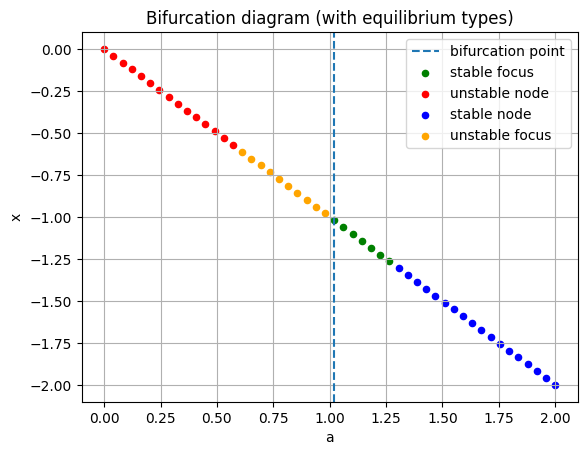

In [55]:
param_name = 'a'
param_values = np.linspace(0, 2, num=50)
state_init = np.array([0, 0])

fig, ax = plt.subplots()

bifurcation_points, equilibria = FHN.plot_bifurcation_diagram(
    param_name=param_name,
    param_values=param_values,
    state_init=state_init,
    ax=ax
)

a_bif = bifurcation_points[0]

4. Построим типичные фазовые портреты для различных значений $a$ по бифуркационной диаграмме.

Limit cycle found!
Limit cycle found!


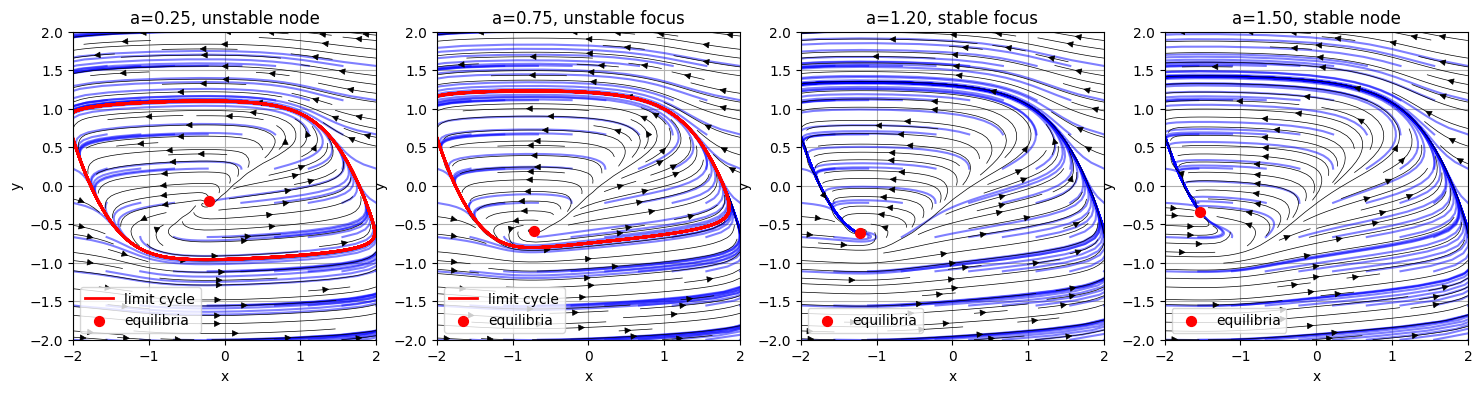

In [ ]:
time_span = np.linspace(0, 50, num=2000)

a_min = param_values[0]
a_max = param_values[-1]
a_values_to_types = [
    (0.25, "unstable node"),
    (0.75, "unstable focus"),
    (1.2, "stable focus"),
    (1.5, "stable node")
]
a_values, equilibrium_types = zip(*a_values_to_types)

equilibria_per_value = np.concatenate((param_values[:, None], equilibria), axis=1)
tolerance = abs(param_values[1] - param_values[0]) / 2

fig, axes = plt.subplots(1, len(a_values_to_types), figsize=(18, 4))

for ax, a, eq_type in zip(axes, a_values, equilibrium_types):
    FHN.params['a'] = a
    FHN.plot_phase_portrait_dense(
        ax=ax,
        time_span=time_span,
        bounds=(-2, 2),
        grid_size=10
    )

    equilibrium_idx = np.isclose(equilibria_per_value[:, 0], a, atol=tolerance)
    equilibrium_value = equilibria_per_value[equilibrium_idx][0]
    equilibrium_point = equilibrium_value[1:]

    ax.scatter(*equilibrium_point, color='red', marker='o', s=50, zorder=100, label='equilibria')
    ax.set_title(f"{a=:.2f}, {eq_type}")
    ax.legend(loc="lower left")

**Итог**. Нейронная модель ФитцХью-Нагумо имеет одну точку бифуркации $a = 1$. При анализе системы была рассмотрена и визуализирована ее единственная равновесная точка. При изменении параметра $a$, равновесная точка меняет тип 3 раза, а также после бифуркации в точке $a = 1$ предельный цикл исчезает.

# 2. Климатическая модель Зальцман-Николис (SN)

$$
\begin{cases}
    \dot{x} = y - x \\
    \dot{y} = -a x + b y - x^2 y
\end{cases}
$$

1. Найдем равновесия системы.

$$
\begin{cases}
    y - x = 0 \\
    -a x + b y - x^2 y = 0
\end{cases}

\implies

\begin{cases}
    x = y \\
    x(x^2 + a - b) = 0
\end{cases}

\implies

\begin{cases}
    (\overline{x}_1, \overline{y}_1) = (0, 0) \\
    (\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
    (\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
\end{cases}
$$

2. Исследуем равновесия на устойчивость.

$$
J(x, y) = \begin{pmatrix}
-1 & 1 \\
-a - 2xy & b - x^2
\end{pmatrix}
$$

$$
|J(x, y) - \lambda E| = 0
$$

$$
\lambda_{1,2}(x, y) = \frac{\pm \sqrt{-4a + b^2 - 2b x^2 + 2b + x^4 - 2x^2 - 8xy + 1} + b - x^2 - 1}{2}
$$

Далее с помощью численной процедуры исследуем поведение собственных чисел якобиана в равновесных точках при различных значениях параметра $a$.

In [19]:
def model_SN(
    time: float,
    state: np.ndarray,
    a: float = 1,
    b: float = 2,
):
    """
    Saltzman-Nicolis climate model.
    Accepts `time` argument for interface consistency, but does not use it.
    
    Parameter restrictions:
    - a > 0
    - b = 2
    """
    x, y = state
    return np.array([
        y - x,
        -a * x + b * y - (x ** 2) * y
    ])

In [ ]:
SN = DynamicSystem2D(
    model_SN,
    params=dict(a=1, b=2)
)

3. Построим бифуркационную диаграмму по параметру $a$ для трех равновесий системы:

$$
\begin{cases}
    (\overline{x}_1, \overline{y}_1) = (0, 0) \\
    (\overline{x}_2, \overline{y}_2) = (\sqrt{b - a}, \sqrt{b - a}) \\
    (\overline{x}_3, \overline{y}_3) = (-\sqrt{b - a}, -\sqrt{b - a})
\end{cases}
$$

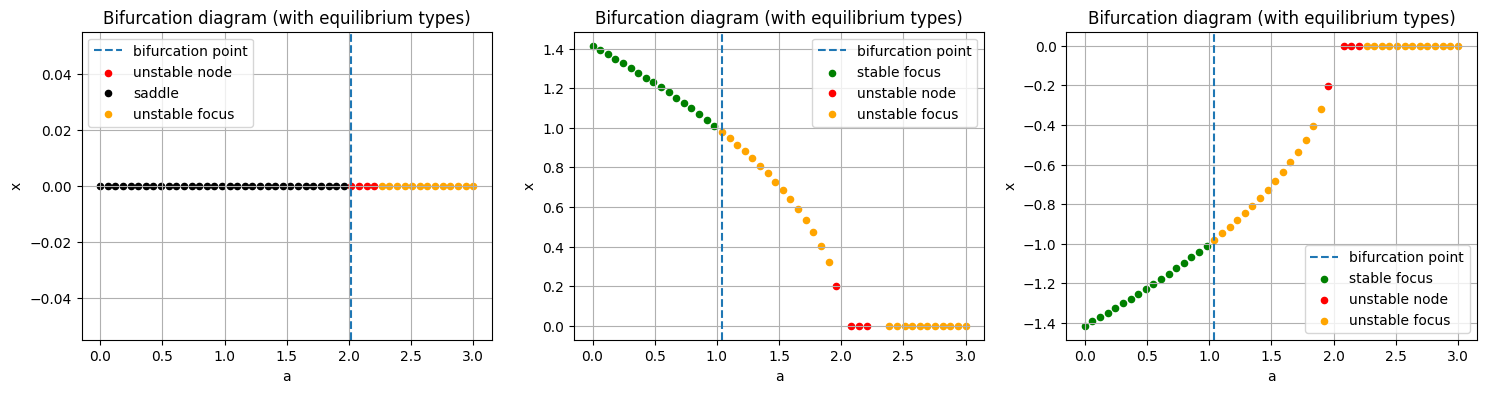

In [58]:
param_name = 'a'
param_values = np.linspace(0, 3, num=50)

b = 2
states_init = [
    np.array([0.1, 0.1]),
    lambda a: np.array([np.sqrt(b - a), np.sqrt(b - a)]),
    lambda a: -np.array([np.sqrt(b - a), np.sqrt(b - a)]),
]
equilibria_per_state = []
bif_points_per_state = []

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for ax, state_init in zip(axes, states_init):
    bifurcation_points, equilibria = SN.plot_bifurcation_diagram(
        param_name=param_name,
        param_values=param_values,
        state_init=state_init,
        ax=ax
    )

    a_bif = bifurcation_points[0]
    equilibria_per_state.append(equilibria)
    bif_points_per_state.append(a_bif)

equilibria = equilibria_per_state[0]
a_bif = bif_points_per_state[0]

4. Построим типичные фазовые портреты для различных значений $a$ по бифуркационной диаграмме равновесия $(\overline{x}_1, \overline{y}_1) = (0, 0)$.

Limit cycle found!
Limit cycle found!
Limit cycle found!


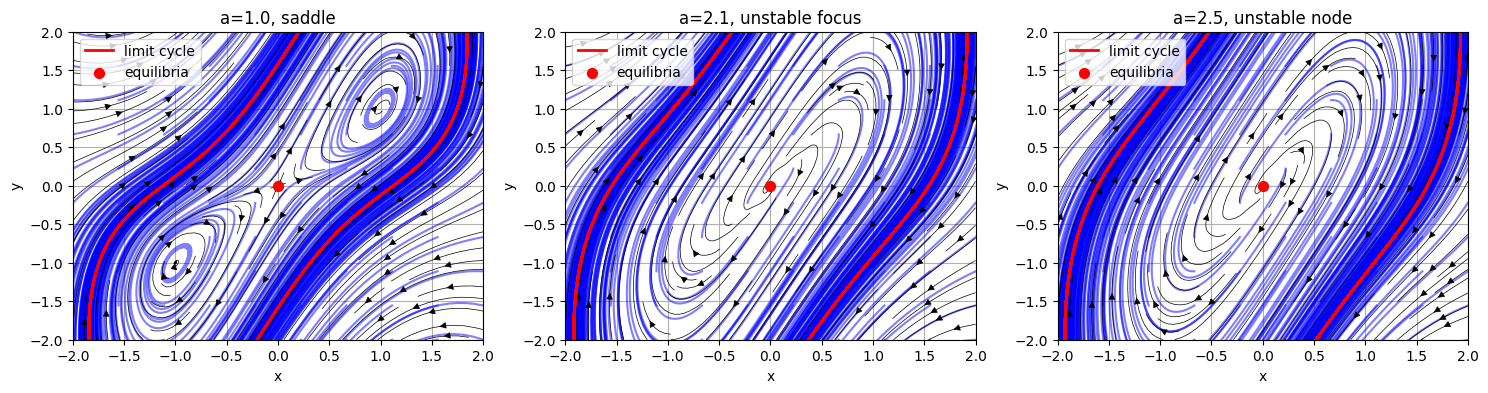

In [59]:
time_span = np.linspace(0, 50, num=2000)

a_min = param_values[0]
a_max = param_values[-1]
a_values_to_types = [
    (1, "saddle"),
    (2.1, "unstable focus"),
    (2.5, "unstable node")
]
a_values, equilibrium_types = zip(*a_values_to_types)

equilibria_per_value = np.concatenate((param_values[:, None], equilibria), axis=1)
tolerance = abs(param_values[1] - param_values[0]) / 2

fig, axes = plt.subplots(1, len(a_values_to_types), figsize=(18, 4))

for ax, a, eq_type in zip(axes, a_values, equilibrium_types):
    SN.params['a'] = a
    SN.plot_phase_portrait_dense(
        ax=ax,
        time_span=time_span,
        bounds=(-2, 2),
        grid_size=10
    )

    equilibrium_idx = np.isclose(equilibria_per_value[:, 0], a, atol=tolerance)
    equilibrium_value = equilibria_per_value[equilibrium_idx][0]
    equilibrium_point = equilibrium_value[1:]

    ax.scatter(*equilibrium_point, color='red', marker='o', s=50, zorder=100, label='equilibria')
    ax.set_title(f"{a=:.1f}, {eq_type}")
    ax.legend(loc="upper left")

**Итог**. Климатическая модель Зальцман-Николис имеет одну точку бифуркации $a = 2$ для равновесия $(\overline{x}_1, \overline{y}_1) = (0, 0)$. При анализе системы была рассмотрена и визуализирована одна действительная равновесная точка из трех существующих. При изменении параметра $a$, равновесная точка меняет тип 2 раза, а также меняется количество и форма предельных цклов.

# TODO
- Рассмотреть все равновесия (в т.ч. устойчивые при a <= 2) для системы SN, изобразить их и предельные циклы вокруг них на фазовых портретах
- Оформить в LaTeX